# **Experiment_6B**

**Given a dataset of five points: A(1,2), B(2,3), C(3,4), D(8,7), and E(9,8). Apply the K-Means clustering algorithm for K = 1, K = 2, and K = 3. For each value of K, compute the cluster centroids and calculate the WCSS (Within-Cluster Sum of Squares). Then, plot the WCSS values against K to illustrate the Elbow Method and determine the optimal number of clusters from the elbow point.**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Dataset
points = np.array([
    [1, 2],  # A
    [2, 3],  # B
    [3, 4],  # C
    [8, 7],  # D
    [9, 8],  # E
], dtype=float)

labels = ["A", "B", "C", "D", "E"]

In [ ]:
# Simple K-Means (KMeans++ init for stable result)
def kmeans(points, k, seed=1, max_iter=100):
    rng = np.random.default_rng(seed)
    n = len(points)

    # KMeans++ init
    centroids = []
    centroids.append(points[rng.integers(0, n)].copy())

    while len(centroids) < k:
        d2 = np.array([min(np.sum((p - c) ** 2) for c in centroids) for p in points])
        if d2.sum() == 0:
            centroids.append(points[rng.integers(0, n)].copy())
            continue
        probs = d2 / d2.sum()
        idx = rng.choice(n, p=probs)
        centroids.append(points[idx].copy())

    centroids = np.array(centroids)

    # Iterate
    for _ in range(max_iter):
        dists = np.linalg.norm(points[:, None, :] - centroids[None, :, :], axis=2)
        assign = np.argmin(dists, axis=1)

        new_centroids = centroids.copy()
        for j in range(k):
            members = points[assign == j]
            if len(members) > 0:
                new_centroids[j] = members.mean(axis=0)

        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids

    # WCSS
    wcss = 0.0
    for i, p in enumerate(points):
        c = centroids[assign[i]]
        wcss += np.sum((p - c) ** 2)

    return assign, centroids, wcss

In [ ]:
# Run for K = 1, 2, 3
wcss_list = []
results = {}

for k in [1, 2, 3]:
    assign, centroids, wcss = kmeans(points, k, seed=1)
    wcss_list.append(wcss)
    results[k] = (assign, centroids, wcss)

    print(f"\n===== K = {k} =====")
    print("Centroids:")
    for i, c in enumerate(centroids):
        print(f"  C{i+1} = ({c[0]:.2f}, {c[1]:.2f})")

    print("Clusters:")
    for cluster_id in range(k):
        members_idx = np.where(assign == cluster_id)[0]
        members = [labels[i] for i in members_idx]
        print(f"  Cluster {cluster_id+1}: {members}")

    print(f"WCSS = {wcss:.2f}")


===== K = 1 =====
Centroids:
  C1 = (4.60, 4.80)
Clusters:
  Cluster 1: ['A', 'B', 'C', 'D', 'E']
WCSS = 80.00

===== K = 2 =====
Centroids:
  C1 = (2.00, 3.00)
  C2 = (8.50, 7.50)
Clusters:
  Cluster 1: ['A', 'B', 'C']
  Cluster 2: ['D', 'E']
WCSS = 5.00

===== K = 3 =====
Centroids:
  C1 = (2.50, 3.50)
  C2 = (8.50, 7.50)
  C3 = (1.00, 2.00)
Clusters:
  Cluster 1: ['B', 'C']
  Cluster 2: ['D', 'E']
  Cluster 3: ['A']
WCSS = 2.00


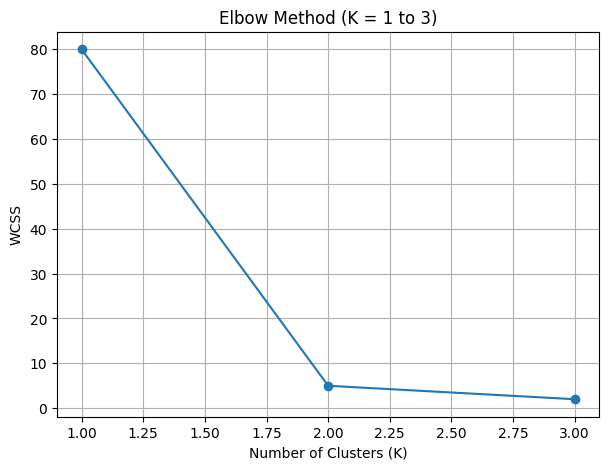

In [ ]:
# Elbow Plot
Ks = [1, 2, 3]
plt.figure(figsize=(7, 5))
plt.plot(Ks, wcss_list, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method (K = 1 to 3)")
plt.grid(True)
plt.show()

In [ ]:
# Simple decision (for this dataset elbow usually at K=2)
print("\n Optimal K (by elbow observation) ≈ 2")


 Optimal K (by elbow observation) ≈ 2
